# Investigate outliers in staph observations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Phylo
import torch
from tqdm import tqdm
import sys
sys.path.append('../pysimARG')
from clonal_genealogy import ClonalTree
from ClonalOrigin_seq_sim import ClonalOrigin_seq_sim

torch_device = "cpu"

## Load simulation data

Load staph gene data and clonal tree.

In [2]:
# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/staph/saureus_clonal.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

                                                                   , C1139
                                                                  ,|
                                                                  |, C9658
                                                                  ||
                                                                  |, C1282
                                                                  ||
                      ____________________________________________|, C1280
                     |                                            ||
                     |                                            || C1080
                     |                                            |
                     |                                            |_ C1079
                     |                                            |
                     |                                            , C1147
                     |                                          

In [3]:
clonal_edge = np.loadtxt("../data/staph/clonal_edge.csv", delimiter=",", dtype=float)
clonal_node_height = np.loadtxt("../data/staph/clonal_node_height.csv", delimiter=",", dtype=float)

np.random.seed(100)
clonal_tree = ClonalTree(n=110)

clonal_tree.edge = clonal_edge
clonal_tree.node_height = clonal_node_height
clonal_tree.height = np.max(clonal_node_height)
clonal_tree.length = np.sum(clonal_edge[:, 2])

In [4]:
x_obs_df = pd.read_csv("../data/staph/core_gene_summary_stats.csv", index_col=0)
x_obs_np = x_obs_df.to_numpy()
x_obs_np.shape

(1983, 46)

### Delete observations with no signal

In [5]:
no_signal_id = np.where(x_obs_np[:, 33] == 0)[0]
no_signal_id.shape, no_signal_id[:10]

((18,), array([ 137,  140,  236,  657,  659,  767,  773, 1036, 1485, 1497]))

In [6]:
x_obs_np = np.delete(x_obs_np, no_signal_id, axis=0)
x_obs_np.shape

(1965, 46)

In [7]:
gene_info = pd.read_csv("../data/staph/core_gene_info.csv", index_col=0)
gene_info_np = gene_info.to_numpy()
gene_info.head()

,Gene_Length,Start_pos,End_pos,Alignment
Gene_ID,,,,
dnaA,1362,517,1878,True
dnaN,1134,2156,3289,True
SAR0003,246,3670,3915,True
recF,1113,3912,5024,True
gyrB,1932,5037,6968,True


In [8]:
gene_info_np = np.delete(gene_info_np, no_signal_id, axis=0)
gene_info_np.shape

(1965, 4)

### Select outliers

In [9]:
out_rho = np.array([82,  174,  256,  259,  263,  313,  338,  349,  387,  390,  420,
                    428,  459,  483,  541,  544,  551,  575,  577,  595,  651,  694,
                    735,  780,  814,  901,  909,  910,  921,  926,  966,  973,  983,
                    1154, 1164, 1186, 1205, 1242, 1330, 1354, 1367, 1379, 1565, 1573,
                    1574, 1576, 1577, 1578, 1623, 1624, 1638, 1639, 1812, 1816, 1839,
                    1855])

In [10]:
out_l = np.array([619])

## Outlier examples

In [11]:
example1 = x_obs_np[82, :]
example2 = x_obs_np[174, :]
example3 = x_obs_np[619, :]
example1, example2, example3

(array([ 8.13540744e+02,  2.79148017e+02,  6.43670491e+04,  2.25966104e+04,
         4.47487413e+03,  1.53779071e+03,  2.23000000e+03,  8.06000000e+02,
         1.24314774e-02,  1.21537799e-02,  9.83573990e-01,  9.83830130e-01,
         6.83792386e-02,  6.69536184e-02,  3.40759757e-02,  3.50923023e-02,
         1.11019008e+01,  1.02901653e+01,  7.41214025e+02,  7.73893819e+02,
         7.03886255e+01,  5.81589719e+01,  9.00000000e+00,  2.20000000e+01,
         1.49219097e-02,  1.31419735e-02,  9.96255410e-01,  9.88370140e-01,
         9.46083676e-02,  7.42771033e-02,  1.20967742e-02,  2.80970626e-02,
         4.20907840e-01,  5.86677815e-02,  7.98385223e+01,  5.92386989e+01,
         1.11307313e+03, -8.66590832e-01,  2.85714286e-02,  5.22565321e-02,
         4.60000000e+01,  6.80088773e-02,  2.81708842e-02,  1.87546735e-02,
         6.73229977e-02,  7.17600000e+03]),
 array([ 1.76280992e+00,  2.12644628e-01,  6.30000000e+01,  1.50000000e+01,
         1.98109604e+01,  2.14517024e+00,  0

In [18]:
drop_columns = list(range(0, 8)) + list(range(16, 32))
print(drop_columns)

[0, 1, 2, 3, 4, 5, 6, 7, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


### Example 1

In [14]:
theta_fix = 0.001133205859498758
delta_fix = 453.6649321544094
L_fix = int(example1[-1])

In [17]:
summary_stats_list = []
rho_list = []
np.random.seed(100)

for i in tqdm(range(100), desc="Processing genes"):
    rand_rho = np.random.uniform(0, 0.1)
    s_vec = ClonalOrigin_seq_sim(clonal_tree, rand_rho, theta_fix, L_fix, delta_fix)
    summary_stats_list.append(s_vec)
    rho_list.append(rand_rho)

Processing genes: 100%|██████████| 100/100 [19:56<00:00, 11.96s/it]


In [19]:
summary_stats_np = np.array(summary_stats_list)
summary_stats_np.shape

(100, 46)

In [22]:
len(rho_list)

100

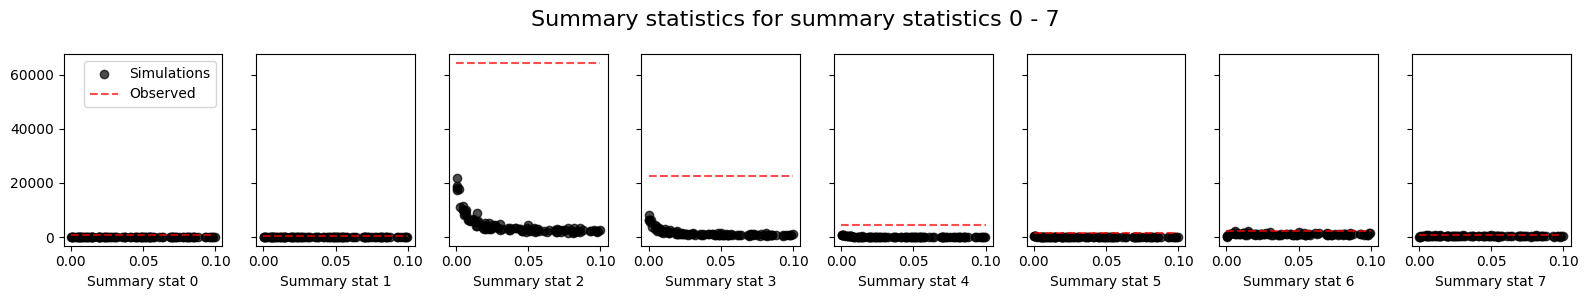

In [30]:
fig, axs = plt.subplots(1, 8, figsize=(16, 3), sharey='row')

for i in range(8):
    axs[i].scatter(rho_list, summary_stats_np[:, i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example1[i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 0 - 7', fontsize=16)
plt.tight_layout()
plt.show()

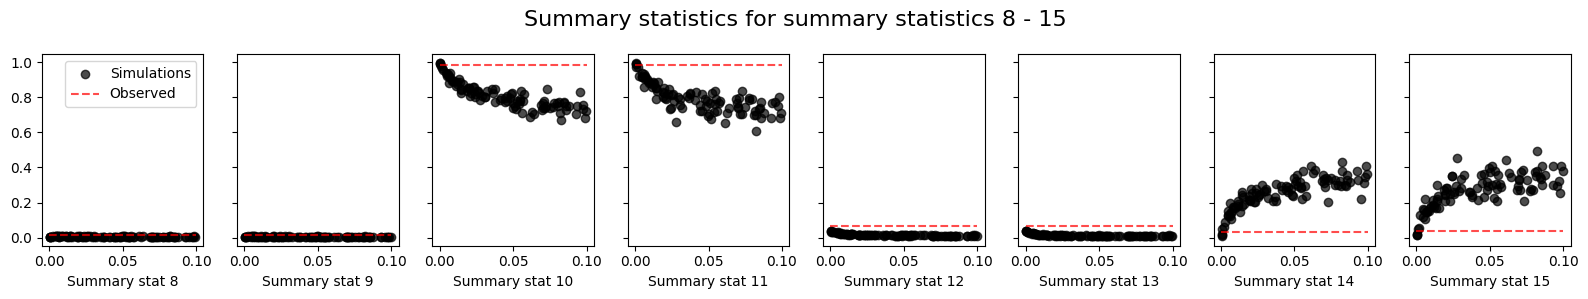

In [32]:
fig, axs = plt.subplots(1, 8, figsize=(16, 3), sharey='row')

for i in range(8):
    axs[i].scatter(rho_list, summary_stats_np[:, 8+i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example1[8+i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {8+i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 8 - 15', fontsize=16)
plt.tight_layout()
plt.show()

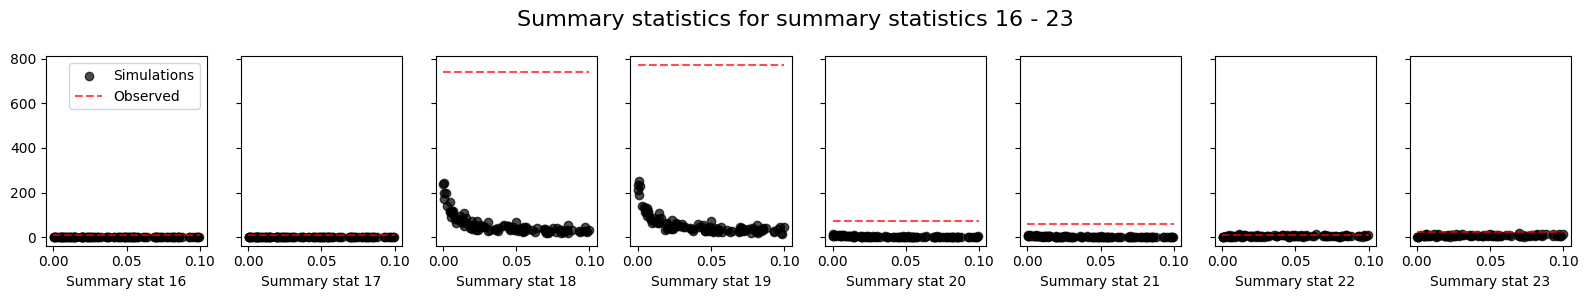

In [33]:
fig, axs = plt.subplots(1, 8, figsize=(16, 3), sharey='row')

for i in range(8):
    axs[i].scatter(rho_list, summary_stats_np[:, 16+i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example1[16+i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {16+i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 16 - 23', fontsize=16)
plt.tight_layout()
plt.show()

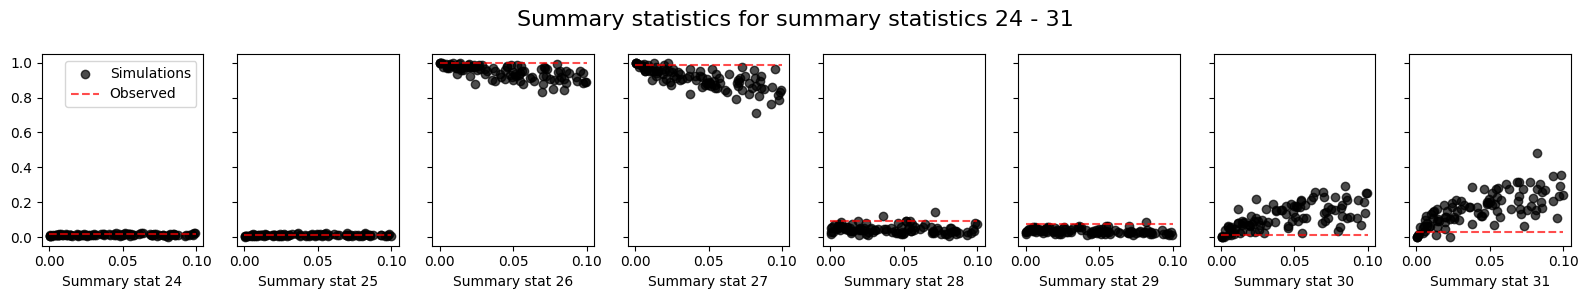

In [34]:
fig, axs = plt.subplots(1, 8, figsize=(16, 3), sharey='row')

for i in range(8):
    axs[i].scatter(rho_list, summary_stats_np[:, 24+i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example1[24+i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {24+i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 24 - 31', fontsize=16)
plt.tight_layout()
plt.show()

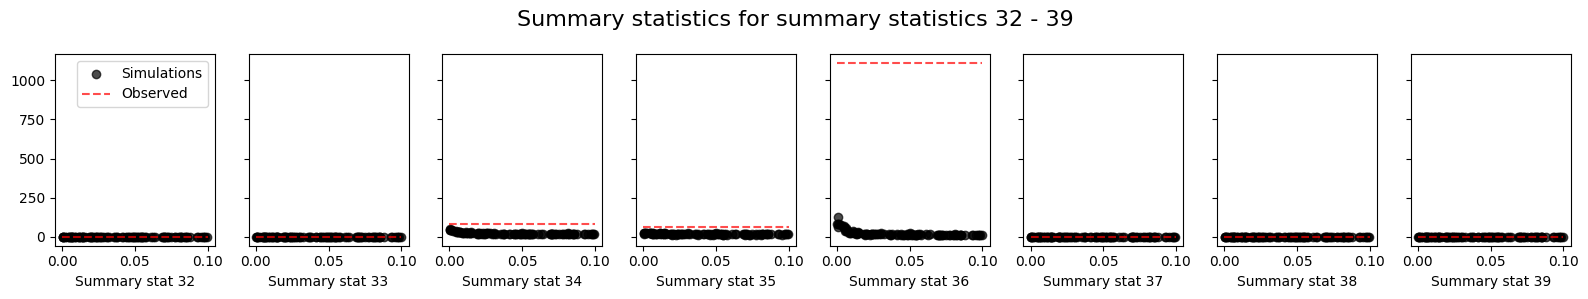

In [35]:
fig, axs = plt.subplots(1, 8, figsize=(16, 3), sharey='row')

for i in range(8):
    axs[i].scatter(rho_list, summary_stats_np[:, 32+i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example1[32+i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {32+i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 32 - 39', fontsize=16)
plt.tight_layout()
plt.show()

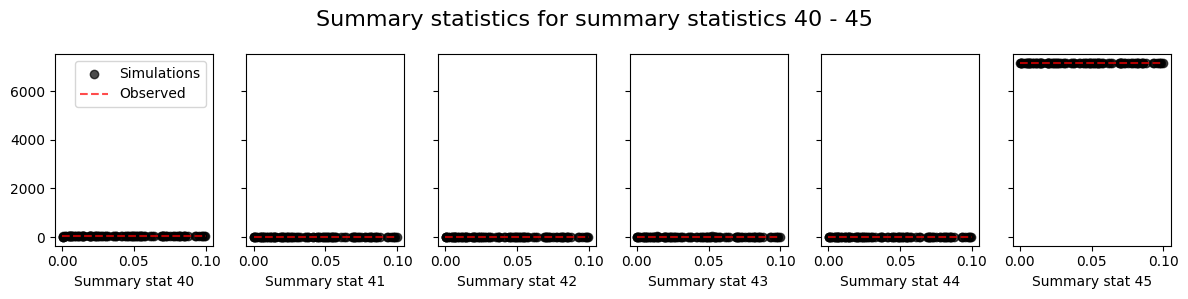

In [37]:
fig, axs = plt.subplots(1, 6, figsize=(12, 3), sharey='row')

for i in range(6):
    axs[i].scatter(rho_list, summary_stats_np[:, 40+i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example1[40+i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {40+i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 40 - 45', fontsize=16)
plt.tight_layout()
plt.show()

### Example 2

In [38]:
theta_fix = 0.001133205859498758
delta_fix = 453.6649321544094
L_fix = int(example2[-1])

In [40]:
summary_stats_list = []
rho_list = []
np.random.seed(123)

for i in tqdm(range(100), desc="Processing genes"):
    rand_rho = np.random.uniform(0, 0.1)
    s_vec = ClonalOrigin_seq_sim(clonal_tree, rand_rho, theta_fix, L_fix, delta_fix)
    summary_stats_list.append(s_vec)
    rho_list.append(rand_rho)

Processing genes: 100%|██████████| 100/100 [00:29<00:00,  3.38it/s]


In [41]:
summary_stats_np = np.array(summary_stats_list)
summary_stats_np.shape

(100, 46)

In [42]:
len(rho_list)

100

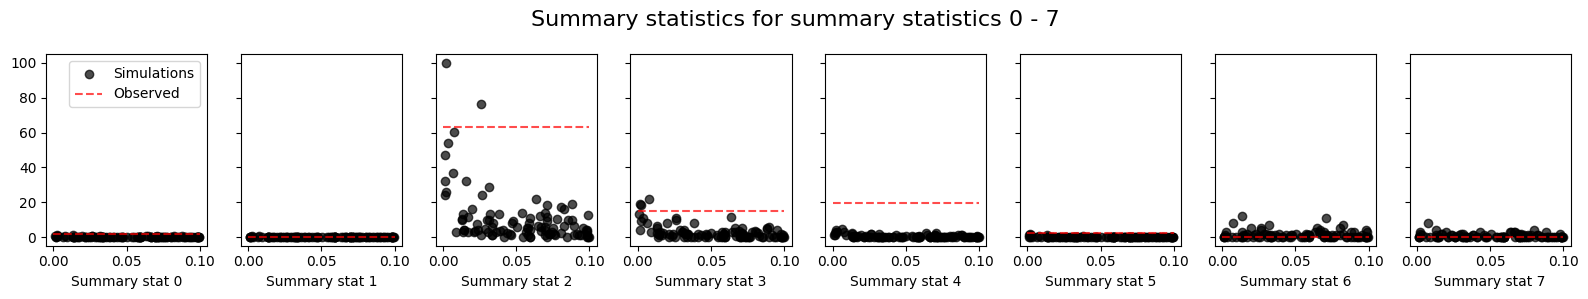

In [43]:
fig, axs = plt.subplots(1, 8, figsize=(16, 3), sharey='row')

for i in range(8):
    axs[i].scatter(rho_list, summary_stats_np[:, i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example2[i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 0 - 7', fontsize=16)
plt.tight_layout()
plt.show()

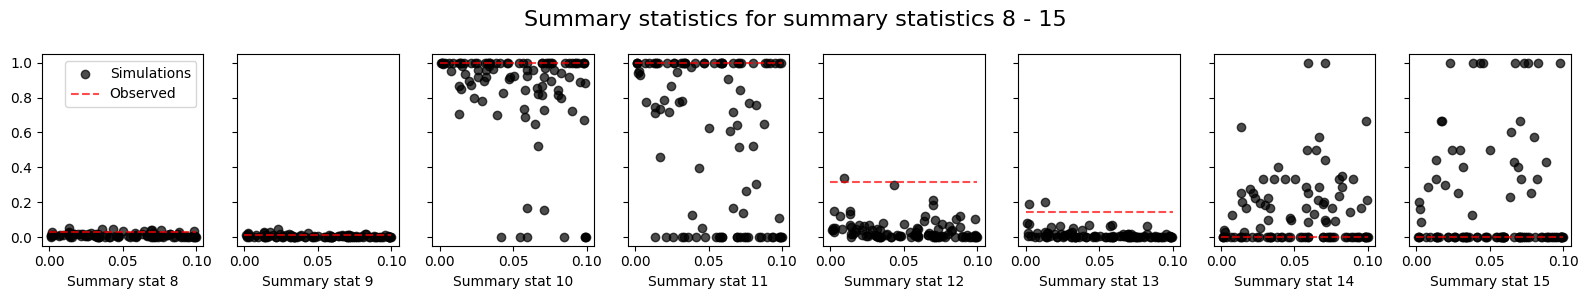

In [44]:
fig, axs = plt.subplots(1, 8, figsize=(16, 3), sharey='row')

for i in range(8):
    axs[i].scatter(rho_list, summary_stats_np[:, 8+i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example2[8+i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {8+i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 8 - 15', fontsize=16)
plt.tight_layout()
plt.show()

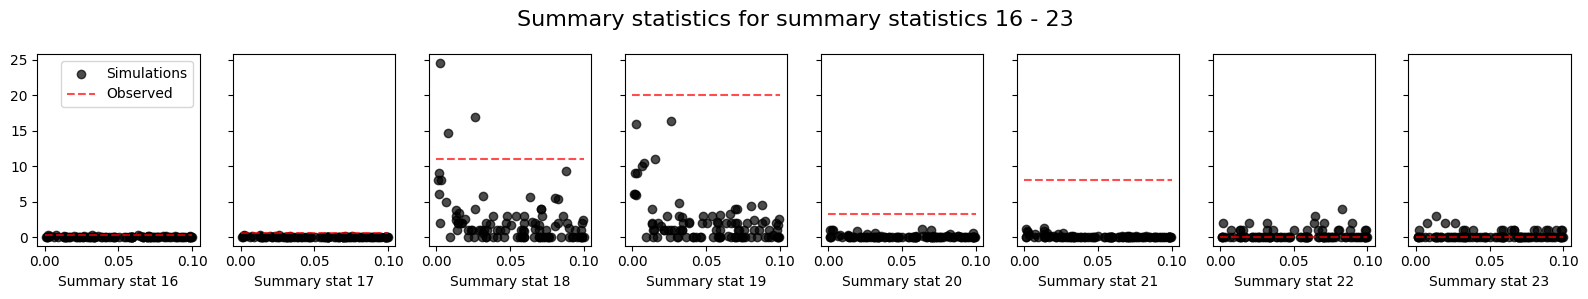

In [45]:
fig, axs = plt.subplots(1, 8, figsize=(16, 3), sharey='row')

for i in range(8):
    axs[i].scatter(rho_list, summary_stats_np[:, 16+i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example2[16+i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {16+i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 16 - 23', fontsize=16)
plt.tight_layout()
plt.show()

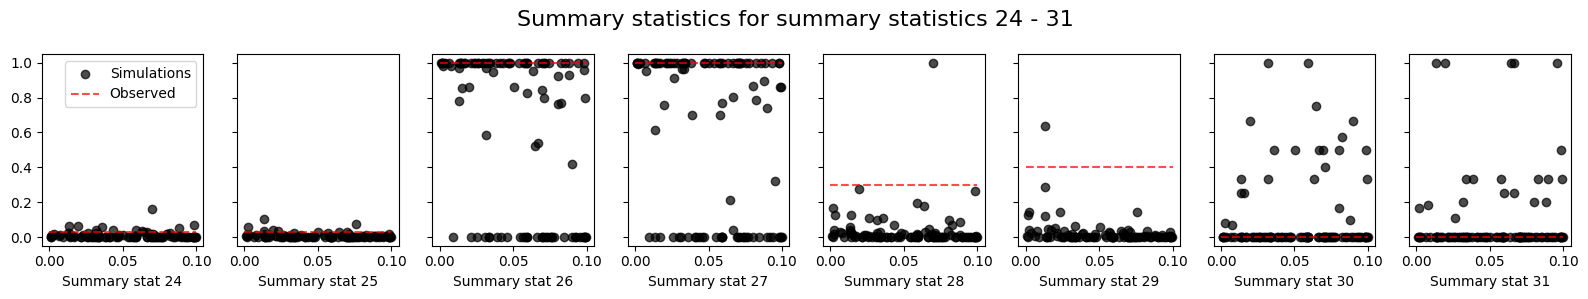

In [46]:
fig, axs = plt.subplots(1, 8, figsize=(16, 3), sharey='row')

for i in range(8):
    axs[i].scatter(rho_list, summary_stats_np[:, 24+i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example2[24+i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {24+i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 24 - 31', fontsize=16)
plt.tight_layout()
plt.show()

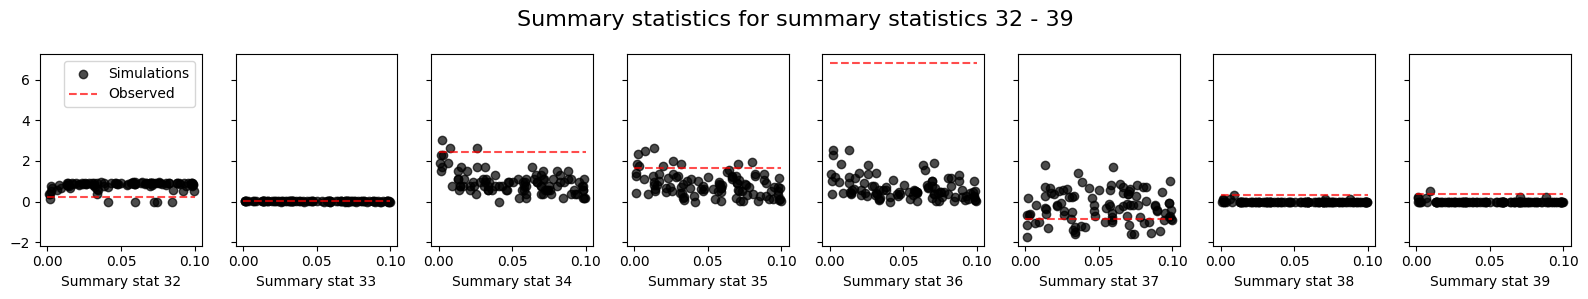

In [47]:
fig, axs = plt.subplots(1, 8, figsize=(16, 3), sharey='row')

for i in range(8):
    axs[i].scatter(rho_list, summary_stats_np[:, 32+i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example2[32+i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {32+i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 32 - 39', fontsize=16)
plt.tight_layout()
plt.show()

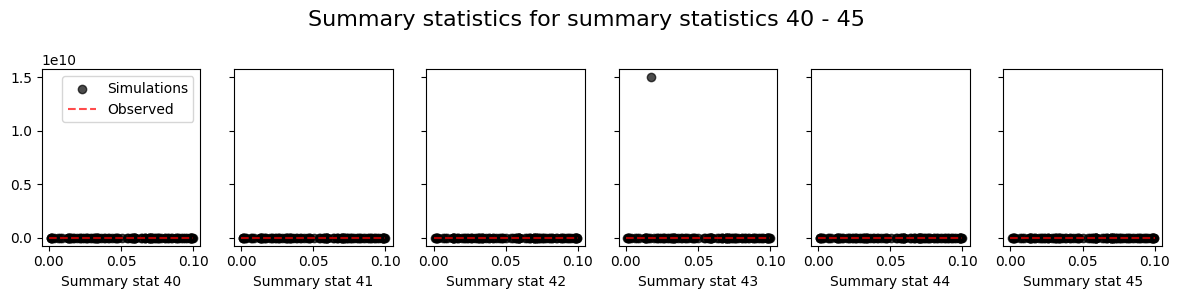

In [48]:
fig, axs = plt.subplots(1, 6, figsize=(12, 3), sharey='row')

for i in range(6):
    axs[i].scatter(rho_list, summary_stats_np[:, 40+i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example2[40+i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {40+i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 40 - 45', fontsize=16)
plt.tight_layout()
plt.show()

### Example 3

In [49]:
theta_fix = 0.001133205859498758
delta_fix = 453.6649321544094
L_fix = int(example3[-1])

In [51]:
summary_stats_list = []
rho_list = []
np.random.seed(1234)

for i in tqdm(range(100), desc="Processing genes"):
    rand_rho = np.random.uniform(0, 0.1)
    s_vec = ClonalOrigin_seq_sim(clonal_tree, rand_rho, theta_fix, L_fix, delta_fix)
    summary_stats_list.append(s_vec)
    rho_list.append(rand_rho)

Processing genes: 100%|██████████| 100/100 [01:16<00:00,  1.31it/s]


In [52]:
summary_stats_np = np.array(summary_stats_list)
summary_stats_np.shape

(100, 46)

In [53]:
len(rho_list)

100

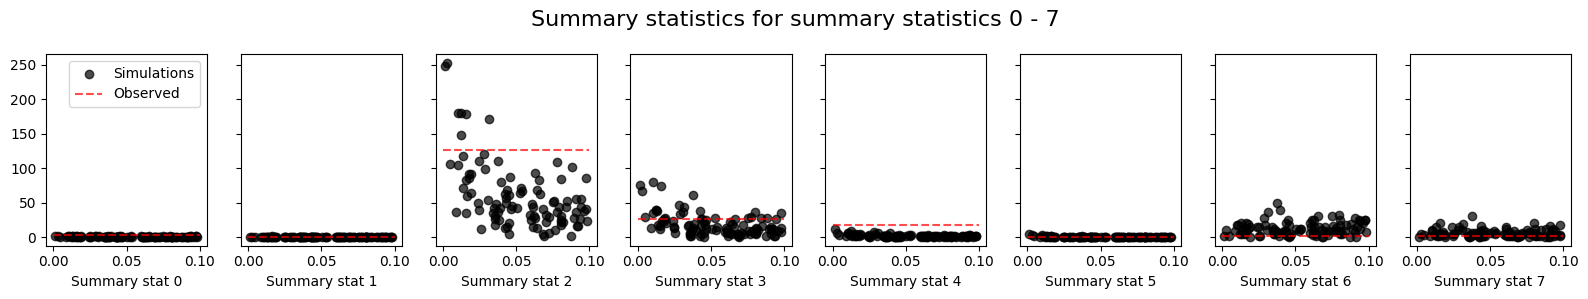

In [54]:
fig, axs = plt.subplots(1, 8, figsize=(16, 3), sharey='row')

for i in range(8):
    axs[i].scatter(rho_list, summary_stats_np[:, i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example3[i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 0 - 7', fontsize=16)
plt.tight_layout()
plt.show()

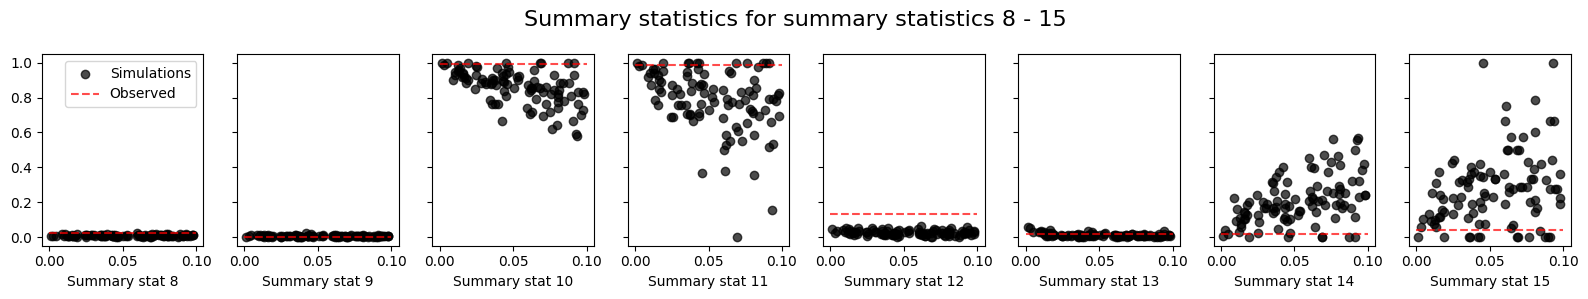

In [55]:
fig, axs = plt.subplots(1, 8, figsize=(16, 3), sharey='row')

for i in range(8):
    axs[i].scatter(rho_list, summary_stats_np[:, 8+i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example3[8+i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {8+i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 8 - 15', fontsize=16)
plt.tight_layout()
plt.show()

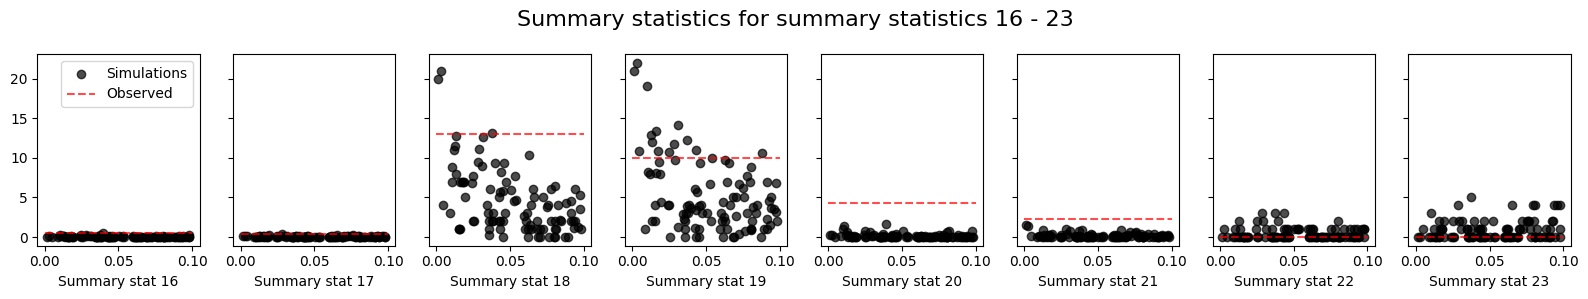

In [56]:
fig, axs = plt.subplots(1, 8, figsize=(16, 3), sharey='row')

for i in range(8):
    axs[i].scatter(rho_list, summary_stats_np[:, 16+i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example3[16+i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {16+i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 16 - 23', fontsize=16)
plt.tight_layout()
plt.show()

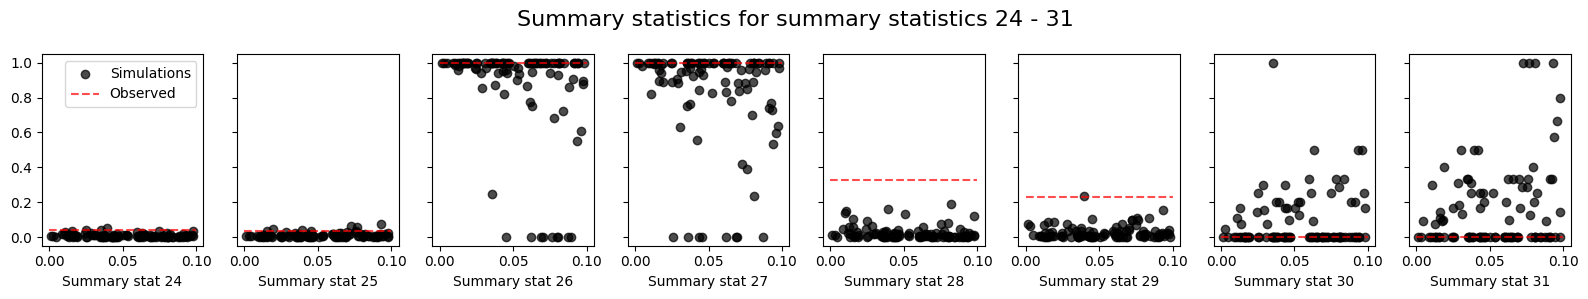

In [57]:
fig, axs = plt.subplots(1, 8, figsize=(16, 3), sharey='row')

for i in range(8):
    axs[i].scatter(rho_list, summary_stats_np[:, 24+i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example3[24+i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {24+i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 24 - 31', fontsize=16)
plt.tight_layout()
plt.show()

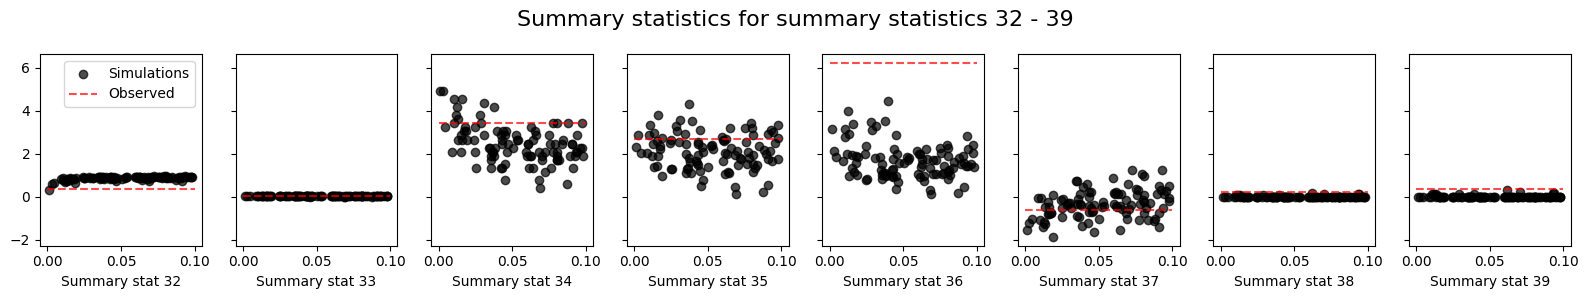

In [58]:
fig, axs = plt.subplots(1, 8, figsize=(16, 3), sharey='row')

for i in range(8):
    axs[i].scatter(rho_list, summary_stats_np[:, 32+i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example3[32+i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {32+i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 32 - 39', fontsize=16)
plt.tight_layout()
plt.show()

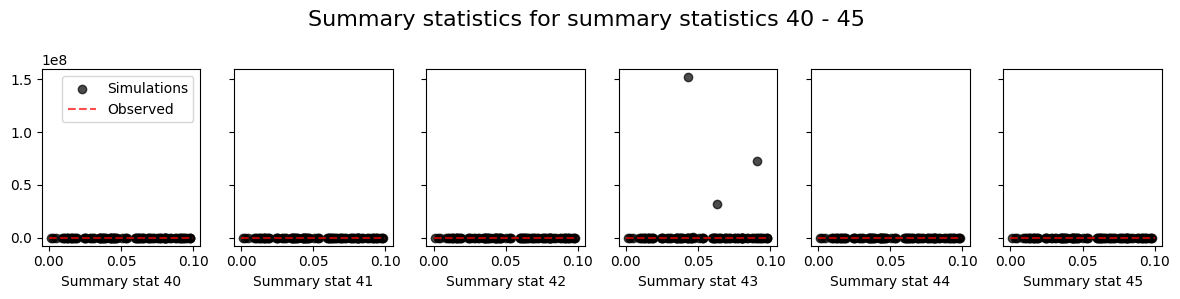

In [59]:
fig, axs = plt.subplots(1, 6, figsize=(12, 3), sharey='row')

for i in range(6):
    axs[i].scatter(rho_list, summary_stats_np[:, 40+i], marker='o', color='black', label="Simulations", alpha=0.7)
    axs[i].hlines(y=example3[40+i], color='red', linestyle='--', label="Observed", alpha=0.7, xmin=0, xmax=0.1)
    axs[i].set_xlabel(f'Summary stat {40+i}')

axs[0].legend(loc='best')
plt.suptitle('Summary statistics for summary statistics 40 - 45', fontsize=16)
plt.tight_layout()
plt.show()